# Gaussian Mixture Modelling - Error Deconvolution

In this notebook I shall demonstrate how to use the machinery defined in this rust crate 

In [17]:
import essrs
import numpy as np
import matplotlib.pyplot as plt

In [18]:
N = 500

# Mean and covariance
mu = np.array([-2.3, 2.7])

X_SIGMA: float = 2.0
Y_SIGMA: float = 3.5
CORR: float = 0.55

Sigma = np.array([
    [X_SIGMA * X_SIGMA, X_SIGMA * Y_SIGMA * CORR],
    [X_SIGMA * Y_SIGMA * CORR, Y_SIGMA * Y_SIGMA]
])

# Cholesky decomposition: Sigma = L @ L.T
L = np.linalg.cholesky(Sigma)

# Sample N independent standard 2D Gaussians
Z = np.random.randn(N, 2)

# Transform to N(mu, Sigma)
X = mu + Z @ L.T

print(X.shape)  # (1000, 2)
print(X)

(500, 2)
[[ 1.23480792e+00  5.70518433e+00]
 [-3.33528265e+00 -2.51548763e+00]
 [-2.42169925e+00  3.30967651e+00]
 [ 2.01114575e+00  1.02878427e+01]
 [-3.13329159e+00  3.71653987e+00]
 [-3.11342216e+00  2.06134697e+00]
 [-2.12768540e+00 -1.13233112e+00]
 [-2.86587935e+00  1.94626787e+00]
 [ 4.19171105e-01  7.32841455e+00]
 [-3.71523999e-01  6.66863253e+00]
 [-3.99838945e+00  4.94463138e+00]
 [-3.45582502e+00 -5.31649372e-01]
 [-4.89800350e-01  6.97707943e+00]
 [-6.99500497e-01  4.85524525e+00]
 [ 1.06169047e+00  8.84513510e+00]
 [ 1.91581604e+00  9.26273381e+00]
 [-5.06515021e+00  2.01308014e-01]
 [-9.22118892e-01  8.44598879e+00]
 [-4.11670014e+00  4.54354452e+00]
 [ 1.72150261e+00  1.23473137e+01]
 [-4.17395835e+00  3.73980099e+00]
 [-2.09080863e+00  5.75826979e+00]
 [-1.31510199e+00 -2.29187319e+00]
 [-8.28685079e-02  3.38237201e+00]
 [-2.04224963e+00 -4.70959840e+00]
 [-2.54710040e+00  2.02922474e+00]
 [-3.00112189e+00  6.80088485e+00]
 [-1.09210006e+00  7.27441914e+00]
 [ 3.453359

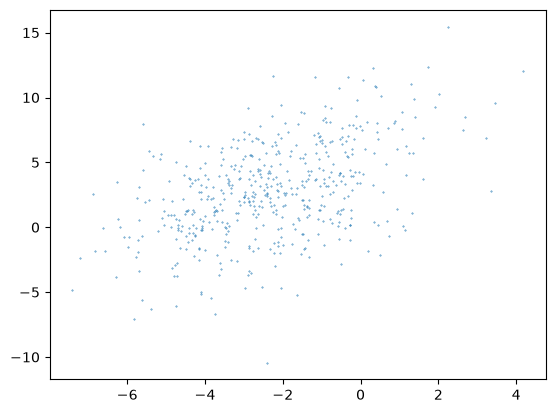

In [19]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1], s=0.5, marker=".")
plt.show()

In [20]:
mu_x = np.mean(X[:, 0])
mu_y = np.mean(X[:, 1])
cov_mat = np.cov(X.T)
print(cov_mat.shape)
print(cov_mat)

x_std = np.sqrt(cov_mat[0, 0])
y_std = np.sqrt(cov_mat[1, 1])

print(x_std, y_std)

p = cov_mat[0, 1] / (x_std * y_std)
print(p)

N_PARAMETERS: int = 5
N_WALKERS: int = 50

ics = np.array([mu_x, mu_y, x_std, y_std, p]) * np.random.normal(1, 0.05, size=(N_WALKERS, N_PARAMETERS))

print(ics)

(2, 2)
[[ 3.78017396  3.42942572]
 [ 3.42942572 13.27552479]]
1.9442669467052514 3.643559357616829
0.4841051009137298
[[-2.18429724  2.86376287  1.98071351  3.6870758   0.48140933]
 [-2.30400815  2.98931251  1.88906181  3.4598019   0.48315459]
 [-2.16850718  2.7063101   1.94834322  3.84969836  0.48837674]
 [-2.24377338  2.69264322  2.02817228  3.62551086  0.45140313]
 [-2.28317009  2.722151    1.94461779  3.92906373  0.51636204]
 [-2.45937815  2.71289049  2.08815124  3.50564991  0.48312382]
 [-2.49943474  2.60232472  2.1207002   3.64225869  0.47223832]
 [-2.57975506  2.88478073  1.91766425  3.12182759  0.48345717]
 [-2.23225718  2.57065246  1.93676404  3.38409238  0.53869678]
 [-2.26807673  2.95334061  1.92711138  3.59253632  0.46157756]
 [-2.28164651  2.79118604  1.97457197  3.6279562   0.50240982]
 [-2.47136142  2.75143795  2.0111739   3.55079589  0.49884579]
 [-2.51754474  3.02753272  1.88712792  3.41260994  0.47676524]
 [-2.26345534  2.98368683  1.91141128  3.540151    0.48943754]


In [21]:
essrs.normal_2d.normal_2d_gmm_deconv

<function normal_2d.normal_2d_gmm_deconv(n_components, max_n_steps, n_burn_in, initial_conditions, data)>

In [22]:
fit = essrs.normal_2d.normal_2d_gmm_deconv(
    1,
    100,
    100,
    ics,
    np.column_stack((X, np.zeros((X.shape[0], 3)))) # pad with zeros for error etc
)

INITIALISATION COMPLETE -- 6 micro-s per walker
Iteration 1 / 100 :: TIME ELAPSED -- 0 SEC [11 TOTAL]
Iteration 2 / 100 :: TIME ELAPSED -- 0 SEC [5 TOTAL]
Iteration 3 / 100 :: TIME ELAPSED -- 0 SEC [3 TOTAL]
Iteration 4 / 100 :: TIME ELAPSED -- 0 SEC [2 TOTAL]
Iteration 5 / 100 :: TIME ELAPSED -- 0 SEC [2 TOTAL]
Iteration 6 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
Iteration 7 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
Iteration 8 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
Iteration 9 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
Iteration 10 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
-- MIN: -1419.050437454073
-- p25: -1415.4780340503053
-- p50: -1414.2093493475613
-- p75: -1413.0843226089426
-- MAX: -1412.130393387278

Iteration 11 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
Iteration 12 / 100 :: TIME ELAPSED -- 0 SEC [1 TOTAL]
Iteration 13 / 100 :: TIME ELAPSED -- 0 SEC [0 TOTAL]
Iteration 14 / 100 :: TIME ELAPSED -- 0 SEC [0 TOTAL]
Iteration 15 / 100 :: TIME ELAPSED -- 0 SEC [0 TOTAL]
Iteration 1

In [23]:

print("Result:")
for i, label in enumerate(["mean X", "mean Y", "sigma X", "sigma Y", "p_corr"]):
    print(f"{label} => {np.mean(fit[-1, :, i].ravel()):7.5f} +- {np.std(fit[-1, :, i].ravel()):7.5f}")


Result:
mean X => -2.32236 +- 0.08979
mean Y => 2.77340 +- 0.18424
sigma X => 1.94938 +- 0.06458
sigma Y => 3.64793 +- 0.09182
p_corr => 0.48478 +- 0.02978
